In [1]:
!ls

cbir  model	 preprocessing	scripts  training
data  notebooks  README.md	test	 utils


In [2]:
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
import pandas as pd

# Load the data
index_ds = pd.read_csv("/mimer/NOBACKUP/groups/biomedicalimaging-kth/felixnie/dataset_index.csv")
clinical_ds = pd.read_csv("/mimer/NOBACKUP/groups/biomedicalimaging-kth/felixnie/combined_metadata.csv")

# Merge on the 'GUID' column
metadata = pd.merge(index_ds, clinical_ds, on="GUID", how="inner")

# Inspect the result
metadata.tail()

,GUID,dataset,batch_file,index_in_batch,index_global,project,subject,timepoint,scan_type,field_strength,manufacturer,model_name,disease,age
23647,fa05462b-4363-4ae8-9ed0-3c85b1fdf6a4,ADNI,/mimer/NOBACKUP/groups/biomedicalimaging-kth/f...,966,23647,adni,128_S_0770,m36,T1,NaN,NaN,NaN,1.0,74.4
23648,fab4a42d-a719-4440-9bab-02cd737e1000,ADNI,/mimer/NOBACKUP/groups/biomedicalimaging-kth/f...,967,23648,adni,141_S_0717,v06,T1,1.5,SIEMENS,Symphony,1.0,81.4
23649,fb2bf1a8-c6ab-4809-9a3c-7daa800b9859,ADNI,/mimer/NOBACKUP/groups/biomedicalimaging-kth/f...,968,23649,adni,009_S_4324,v41,T1,3.0,SIEMENS,Verio,1.0,67.2
23650,fde83ef6-cb7f-457d-9e21-9c35fada74a9,ADNI,/mimer/NOBACKUP/groups/biomedicalimaging-kth/f...,969,23650,adni,129_S_1246,m06,T1,1.5,GE MEDICAL SYSTEMS,GENESIS_SIGNA,1.0,73.2
23651,fee2f1a0-af46-4368-9e75-20572f4d79c4,ADNI,/mimer/NOBACKUP/groups/biomedicalimaging-kth/f...,970,23651,adni,033_S_6352,init,T1,NaN,NaN,NaN,0.0,NaN


In [4]:
print(f"Original rows: {len(metadata)}")

# First, ensure empty strings are treated as NaN
metadata['subject'].replace('', pd.NA, inplace=True)

# Then drop rows where subject is NaN
metadata = metadata.dropna(subset=['subject'])

# Optional: reset index
metadata = metadata.reset_index(drop=True)

# Check result
print(f"Remaining rows: {len(metadata)}")


Original rows: 23652
Remaining rows: 23652


In [14]:
import torch
import numpy as np
from torch.utils.data import Dataset
import gc
import random
from collections import defaultdict
from model.losses import MultiPosConLoss
from preprocessing.load_dataset import LookupNPZDataset, get_balanced_batch

def mock_get_balanced_batch(device, feats_flatten=False):
    if feats_flatten:
        return {
                'feats': torch.rand((12, 3, 20, 22, 26)).to(device).flatten(), # B, C, ...
                'labels': torch.Tensor(np.array([0,0,0,1,1,1,2,2,2], dtype=float)).to(device)
            }
    else:
        return {
                'feats': torch.rand((12, 3, 20, 22, 26)).to(device), # B, C, ...
                'labels': torch.Tensor(np.array([0,0,0,1,1,1,2,2,2], dtype=float)).to(device)
            }

# Training configuration
num_epochs = 10
loss_fn = MultiPosConLoss(temperature=0.2)
device = "cuda" if torch.cuda.is_available() else "cpu"
batch_files = sorted(metadata["batch_file"].unique())

for epoch in range(num_epochs):
    random.shuffle(batch_files)

    for batch_file in batch_files:
        # dataset = LookupNPZDataset(metadata, batch_file=batch_file, use_segmentation=False)

        for _ in range(5):  # loop over several batches per file
            # batch = get_balanced_batch(dataset, device=device)
            batch = mock_get_balanced_batch(device, feats_flatten=True)

            if batch["feats"].shape[0] < 6:
                continue  # skip too-small batches

            loss_dict = loss_fn(batch)
            print(f"Epoch {epoch} | Loss: {loss_dict['loss'].item():.4f}")
            halt

Epoch 0 | Loss: 2.0794


NameError: name 'halt' is not defined

{'feats': tensor([[[[[8.9080e-01, 2.9530e-01, 9.1336e-01,  ..., 5.2627e-01,
             3.7399e-01, 1.8165e-01],
            [9.5492e-01, 3.4353e-01, 3.6721e-01,  ..., 3.3105e-01,
             1.6835e-01, 1.6234e-01],
            [1.0981e-01, 3.7514e-01, 1.7767e-01,  ..., 3.8842e-01,
             5.1346e-01, 7.8274e-02],
            ...,
            [1.1830e-01, 1.7796e-01, 6.0498e-01,  ..., 5.8210e-01,
             6.6454e-01, 2.5963e-01],
            [8.0124e-01, 8.3997e-01, 6.7849e-01,  ..., 9.5183e-02,
             9.0179e-01, 7.1543e-01],
            [6.7080e-01, 1.5596e-01, 7.3647e-01,  ..., 4.1827e-03,
             1.9317e-01, 3.6374e-01]],
 
           [[1.9158e-01, 8.3085e-01, 6.1559e-01,  ..., 2.7156e-01,
             2.4654e-01, 1.4055e-01],
            [2.5581e-01, 4.0479e-01, 4.7299e-02,  ..., 9.6013e-01,
             1.1081e-01, 7.8736e-01],
            [1.8063e-01, 7.2752e-02, 1.0559e-01,  ..., 3.0119e-01,
             4.2166e-01, 4.3814e-01],
            ...,
         

In [ ]:
output

{'feats': tensor([[[[[0., 0., 0.,  ..., 0., 0., 0.],
            [0., 0., 0.,  ..., 0., 0., 0.],
            [0., 0., 0.,  ..., 0., 0., 0.],
            ...,
            [0., 0., 0.,  ..., 0., 0., 0.],
            [0., 0., 0.,  ..., 0., 0., 0.],
            [0., 0., 0.,  ..., 0., 0., 0.]],
 
           [[0., 0., 0.,  ..., 0., 0., 0.],
            [0., 0., 0.,  ..., 0., 0., 0.],
            [0., 0., 0.,  ..., 0., 0., 0.],
            ...,
            [0., 0., 0.,  ..., 0., 0., 0.],
            [0., 0., 0.,  ..., 0., 0., 0.],
            [0., 0., 0.,  ..., 0., 0., 0.]],
 
           [[0., 0., 0.,  ..., 0., 0., 0.],
            [0., 0., 0.,  ..., 0., 0., 0.],
            [0., 0., 0.,  ..., 0., 0., 0.],
            ...,
            [0., 0., 0.,  ..., 0., 0., 0.],
            [0., 0., 0.,  ..., 0., 0., 0.],
            [0., 0., 0.,  ..., 0., 0., 0.]],
 
           ...,
 
           [[0., 0., 0.,  ..., 0., 0., 0.],
            [0., 0., 0.,  ..., 0., 0., 0.],
            [0., 0., 0.,  ..., 0.

In [ ]:
np.array(output['feats'].shape)/2/2/2, output['feats'].shape

(array([ 1.5  ,  0.125, 20.   , 22.   , 26.   ]),
 torch.Size([12, 1, 160, 176, 208]))

In [ ]:
np.random.uniform(0,1, (12, 3, 20, 22, 26)).shape # B, C, ...

(12, 3, 20, 22, 26)

tensor([0., 0., 0., 1., 1., 1., 2., 2., 2.])

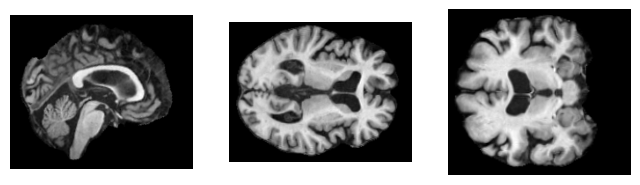

In [ ]:
mri_image = images[0]
# Show a single slice (assuming 3D MRI data)
fig, axes = plt.subplots(1, 3, figsize=(8, 10))
axes[0].imshow(mri_image[mri_image.shape[0] // 2, : ,:], cmap="gray")
axes[0].axis("off")
axes[1].imshow(mri_image[:, mri_image.shape[1] // 2, :], cmap="gray")
axes[1].axis("off")
axes[2].imshow(mri_image[:, :, mri_image.shape[2] // 2], cmap="gray")
axes[2].axis("off")
plt.show()

In [ ]:
mri_image.cpu().numpy(),.shape

NameError: name 'mri_image' is not defined